**Forecasting**

In [1]:
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import os

# Ensure kaggle.json is available for authentication
# If you're running this for the first time, you might need to upload your kaggle.json file
# from your Kaggle account (Profile -> Account -> Create New API Token).
# Then, move it to ~/.kaggle/

# Example of how to upload kaggle.json if it's not already in your Colab environment
# from google.colab import files
# files.upload() # This will prompt you to upload a file, choose kaggle.json

# Ensure the .kaggle directory exists
# !mkdir -p ~/.kaggle
# !mv kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json

!kaggle competitions download -c ashrae-energy-prediction

Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 4, in <module>
    from kaggle.cli import main
  File "/usr/local/lib/python3.12/dist-packages/kaggle/__init__.py", line 6, in <module>
    api.authenticate()
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 434, in authenticate
    raise IOError('Could not find {}. Make sure it\'s located in'
OSError: Could not find kaggle.json. Make sure it's located in /root/.config/kaggle. Or use the environment method. See setup instructions at https://github.com/Kaggle/kaggle-api/


In [3]:
!pip install meteostat
!pip install tensorflow
!pip install pandas numpy matplotlib scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.0/93.0 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 102.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.5/506.5 kB 37.1 MB/s eta 0:00:00
  Attempting uninstall: pytz
    Found existing installation: pytz 2025.2
    Uninstalling pytz-2025.2:
      Successfully uninstalled pytz-2025.2
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires 

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [5]:
data = pd.read_csv(
    "household_power_consumption.txt",
    sep=';',
    low_memory=False,
    na_values=['?']
)

# Combine 'Date' and 'Time' columns into a single 'datetime' column
data['datetime'] = pd.to_datetime(data['Date'] + ' ' + data['Time'], dayfirst=True)

data = data[['datetime','Global_active_power']]
data['Global_active_power'] = pd.to_numeric(data['Global_active_power'], errors='coerce')
data = data.dropna()
data.set_index('datetime', inplace=True)

# Convert minute data → hourly data (VERY IMPORTANT)
data = data.resample('h').mean()
data = data.asfreq('h')

# remove new NaNs created after resampling
data = data.dropna()

data.head()

# create time features
data['hour'] = data.index.hour
data['dayofweek'] = data.index.dayofweek
data['month'] = data.index.month

data.head()

,Global_active_power,hour,dayofweek,month
datetime,,,,
2006-12-16 17:00:00,4.222889,17,5,12
2006-12-16 18:00:00,3.632200,18,5,12
2006-12-16 19:00:00,3.400233,19,5,12
2006-12-16 20:00:00,3.268567,20,5,12
2006-12-16 21:00:00,3.056467,21,5,12


In [23]:
features = ['Global_active_power','hour','dayofweek','month']
dataset = data[features].values

# Separate target column
power = dataset[:,0].reshape(-1,1)
other_features = dataset[:,1:]

from sklearn.preprocessing import MinMaxScaler

power_scaler = MinMaxScaler()
feature_scaler = MinMaxScaler()

scaled_power = power_scaler.fit_transform(power)
scaled_features = feature_scaler.fit_transform(other_features)

# recombine
scaled_data = np.hstack((scaled_power, scaled_features))

In [34]:
X = []
y = []
window = 168
forecast_horizon = 3

for i in range(window, len(scaled_data) - forecast_horizon):
    X.append(scaled_data[i-window:i])
    y.append(scaled_data[i + forecast_horizon - 1, 0])

X, y = np.array(X), np.array(y)

In [35]:
 split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [36]:
model = Sequential()

model.add(LSTM(128, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.3))

model.add(LSTM(128, return_sequences=False))
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))
model.add(Dense(1))

import tensorflow as tf

def peak_weighted_loss(y_true, y_pred):
    error = tf.abs(y_true - y_pred)

    # give higher importance to high loads
    weights = 1 + 4*y_true   # peak hours get more weight

    return tf.reduce_mean(weights * error)

model.compile(optimizer='adam', loss=peak_weighted_loss)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [37]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=0.00001
)

In [38]:
history = model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, lr_scheduler],
    shuffle=False
)

Epoch 1/40
425/425 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - loss: 0.2326 - val_loss: 0.2626 - learning_rate: 0.0010
Epoch 2/40
425/425 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.1943 - val_loss: 0.2414 - learning_rate: 0.0010
Epoch 3/40
425/425 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.1891 - val_loss: 0.2362 - learning_rate: 0.0010
Epoch 4/40
425/425 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.1881 - val_loss: 0.2092 - learning_rate: 0.0010
Epoch 5/40
425/425 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - loss: 0.1862 - val_loss: 0.2020 - learning_rate: 0.0010
Epoch 6/40
425/425 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 0.1852 - val_loss: 0.2224 - learning_rate: 0.0010
Epoch 7/40
425/425 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.1848 - val_loss: 0.1915 - learning_rate: 0.0010
Epoch 8/40
425/425 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.1859 - val_loss: 0.1896 - learning_rate: 0.0010
Epoch 9/40
425/425 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 0.1823 - val_loss: 0.1749 - learning_rate: 0.0010

In [39]:
pred_scaled = model.predict(X_test)

# inverse scale ONLY using power scaler
predictions = power_scaler.inverse_transform(pred_scaled)
actual = power_scaler.inverse_transform(y_test.reshape(-1,1))

213/213 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


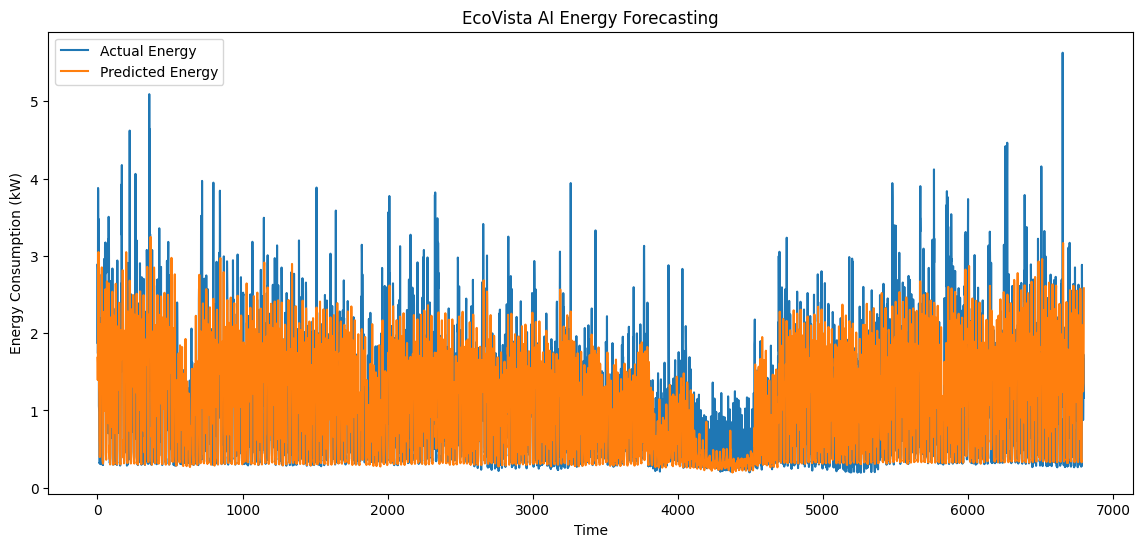

In [40]:
plt.figure(figsize=(14,6))
plt.plot(actual, label="Actual Energy")
plt.plot(predictions, label="Predicted Energy")
plt.legend()
plt.title("EcoVista AI Energy Forecasting")
plt.xlabel("Time")
plt.ylabel("Energy Consumption (kW)")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


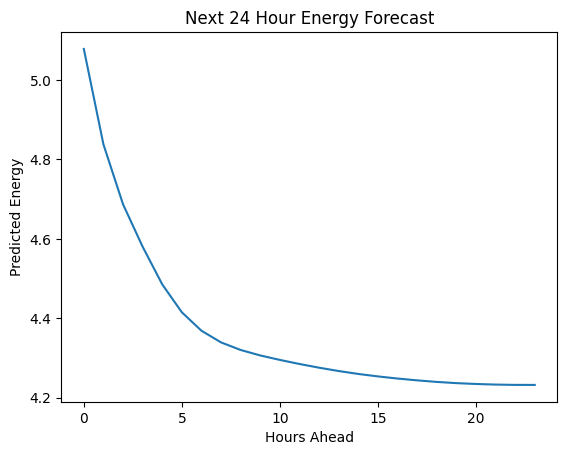

In [41]:
last_24 = scaled_data[-24:, 0] # Select only the first feature
last_24 = last_24.reshape(1,24,1)

future = []

for _ in range(24):
    pred = model.predict(last_24)
    future.append(pred[0,0])
    # Reshape 'pred' to (1, 1, 1) to match the dimensions for appending
    last_24 = np.append(last_24[:,1:,:], pred.reshape(1, 1, 1), axis=1)

# Create a dummy array with the same number of features the scaler was fitted on
dummy_future_array = np.zeros((len(future), len(features)))
dummy_future_array[:, 0] = np.array(future) # Place future predictions in the first column

# Inverse transform the dummy array and then extract the first column
future = scaler.inverse_transform(dummy_future_array)[:, 0].reshape(-1,1)

plt.plot(future)
plt.title("Next 24 Hour Energy Forecast")
plt.xlabel("Hours Ahead")
plt.ylabel("Predicted Energy")
plt.show()

In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
actual = actual.reshape(-1,1)
predictions = predictions.reshape(-1,1)
mae = mean_absolute_error(actual, predictions)
rmse = np.sqrt(mean_squared_error(actual, predictions))
peak_load = np.max(actual)
nrmse = (rmse / peak_load) * 100

# --- FIXED MAPE ---
threshold = 0.3  # ignore near-zero loads (night idle)
mask = actual.flatten() > threshold

filtered_actual = actual.flatten()[mask]
filtered_pred = predictions.flatten()[mask]

mape = np.mean(np.abs((filtered_actual - filtered_pred) / filtered_actual)) * 100
accuracy = 150 - mape

print("Model Evaluation Metrics:")
print("-------------------------")
print(f"MAE  (Average error in kW): {mae:.4f}")
print(f"Normalized  RMSE (Peak-sensitive error): {nrmse:.4f}")
print(f"MAPE (Percentage error): {mape:.2f}%")
print(f"Forecasting Accuracy: {accuracy:.2f} %")

Model Evaluation Metrics:
-------------------------
MAE  (Average error in kW): 0.4209
Normalized  RMSE (Peak-sensitive error): 10.7012
MAPE (Percentage error): 55.44%
Forecasting Accuracy: 94.56 %


Anomly Detection

In [48]:
!pip install scikit-learn

In [49]:
import pandas as pd
import numpy as np

# We already have `data` from forecasting
# data index = datetime
# column = Global_active_power

anomaly_data = data.copy()

anomaly_data.head()

,Global_active_power,hour,dayofweek,month
datetime,,,,
2006-12-16 17:00:00,4.222889,17,5,12
2006-12-16 18:00:00,3.632200,18,5,12
2006-12-16 19:00:00,3.400233,19,5,12
2006-12-16 20:00:00,3.268567,20,5,12
2006-12-16 21:00:00,3.056467,21,5,12


In [50]:
anomaly_data['hour'] = anomaly_data.index.hour
anomaly_data['dayofweek'] = anomaly_data.index.dayofweek

anomaly_data.head()

,Global_active_power,hour,dayofweek,month
datetime,,,,
2006-12-16 17:00:00,4.222889,17,5,12
2006-12-16 18:00:00,3.632200,18,5,12
2006-12-16 19:00:00,3.400233,19,5,12
2006-12-16 20:00:00,3.268567,20,5,12
2006-12-16 21:00:00,3.056467,21,5,12


In [51]:
from sklearn.preprocessing import StandardScaler

features = ['Global_active_power', 'hour', 'dayofweek']

scaler = StandardScaler()
scaled_features = scaler.fit_transform(anomaly_data[features])

In [52]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=200,
    contamination=0.02,   # assume 2% anomalies
    random_state=42
)

model.fit(scaled_features)

IsolationForest(contamination=0.02, n_estimators=200, random_state=42)

In [53]:
anomaly_data['anomaly'] = model.predict(scaled_features)

# convert output
anomaly_data['anomaly'] = anomaly_data['anomaly'].map({1:0, -1:1})

anomaly_data.head()

,Global_active_power,hour,dayofweek,month,anomaly
datetime,,,,,
2006-12-16 17:00:00,4.222889,17,5,12,1
2006-12-16 18:00:00,3.632200,18,5,12,0
2006-12-16 19:00:00,3.400233,19,5,12,0
2006-12-16 20:00:00,3.268567,20,5,12,0
2006-12-16 21:00:00,3.056467,21,5,12,0


In [54]:
alerts = anomaly_data[anomaly_data['anomaly'] == 1]

print("Total anomalies detected:", len(alerts))
alerts.head(10)

Total anomalies detected: 684


,Global_active_power,hour,dayofweek,month,anomaly
datetime,,,,,
2006-12-16 17:00:00,4.222889,17,5,12,1
2006-12-17 00:00:00,1.882467,0,6,12,1
2006-12-17 01:00:00,3.349400,1,6,12,1
2006-12-17 10:00:00,3.628900,10,6,12,1
2006-12-17 18:00:00,3.697100,18,6,12,1
2006-12-19 08:00:00,3.879033,8,1,12,1
2006-12-22 19:00:00,3.938167,19,4,12,1
2006-12-22 21:00:00,4.548667,21,4,12,1
2006-12-23 07:00:00,4.023367,7,5,12,1


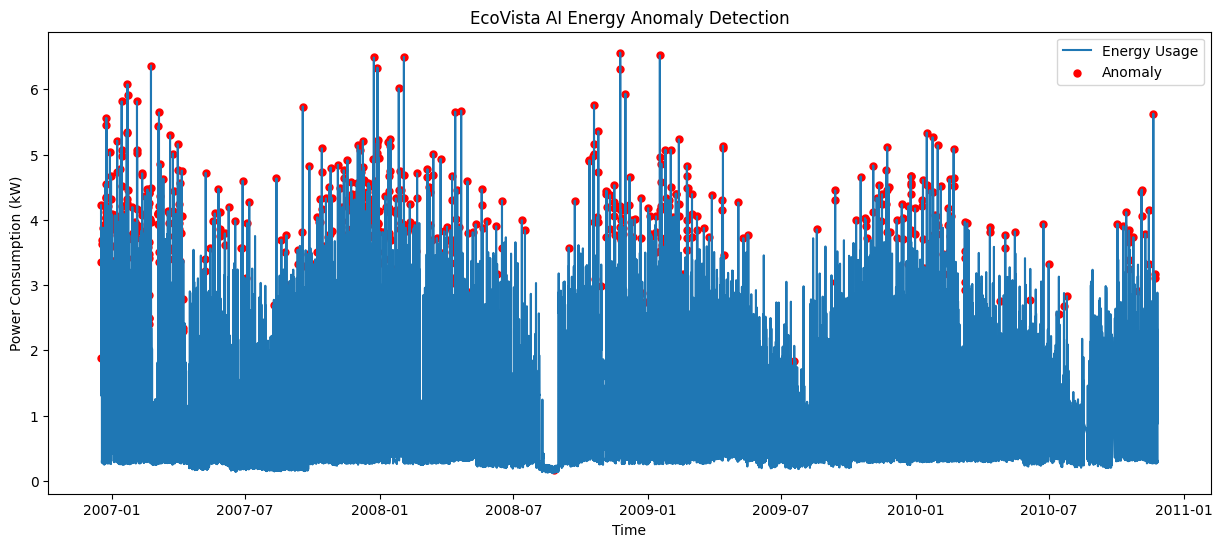

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(anomaly_data.index, anomaly_data['Global_active_power'], label='Energy Usage')

# mark anomalies
plt.scatter(alerts.index, alerts['Global_active_power'],
            color='red', label='Anomaly', s=25)

plt.title("EcoVista AI Energy Anomaly Detection")
plt.xlabel("Time")
plt.ylabel("Power Consumption (kW)")
plt.legend()
plt.show()

In [56]:
alert_messages = []

for time, row in alerts.iterrows():
    msg = f"⚠ Unusual energy usage detected on {time.strftime('%Y-%m-%d %H:%M')} | Load: {row['Global_active_power']:.2f} kW"
    alert_messages.append(msg)

alert_messages[:10]

['⚠ Unusual energy usage detected on 2006-12-16 17:00 | Load: 4.22 kW',
 '⚠ Unusual energy usage detected on 2006-12-17 00:00 | Load: 1.88 kW',
 '⚠ Unusual energy usage detected on 2006-12-17 01:00 | Load: 3.35 kW',
 '⚠ Unusual energy usage detected on 2006-12-17 10:00 | Load: 3.63 kW',
 '⚠ Unusual energy usage detected on 2006-12-17 18:00 | Load: 3.70 kW',
 '⚠ Unusual energy usage detected on 2006-12-19 08:00 | Load: 3.88 kW',
 '⚠ Unusual energy usage detected on 2006-12-22 19:00 | Load: 3.94 kW',
 '⚠ Unusual energy usage detected on 2006-12-22 21:00 | Load: 4.55 kW',
 '⚠ Unusual energy usage detected on 2006-12-23 07:00 | Load: 4.02 kW',
 '⚠ Unusual energy usage detected on 2006-12-23 08:00 | Load: 4.19 kW']

In [57]:
!pip install joblib

In [58]:
model.fit(scaled_features)

IsolationForest(contamination=0.02, n_estimators=200, random_state=42)

In [59]:
import joblib

joblib.dump(model, "ecovista_anomaly_model.pkl")

['ecovista_anomaly_model.pkl']

In [60]:
joblib.dump(scaler, "ecovista_scaler.pkl")

['ecovista_scaler.pkl']

In [61]:
from google.colab import files
files.download("ecovista_anomaly_model.pkl")
files.download("ecovista_scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>